In [1]:
# Im trying to generate synthetic sugar for finance

In [141]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from scipy.interpolate import UnivariateSpline

In [63]:
x = np.linspace(start=0, stop=2*np.pi, num=1000)
x1 = np.concatenate((np.sin(1*x), np.zeros_like(x), np.zeros_like(x)))
x2 = np.concatenate((np.sin(2*x), np.zeros_like(x), np.zeros_like(x)))
x3 = np.concatenate((np.sin(3*x), np.zeros_like(x), np.zeros_like(x)))
x4 = np.concatenate((np.sin(4*x), np.zeros_like(x), np.zeros_like(x)))
x5 = np.concatenate((np.sin(5*x), np.zeros_like(x), np.zeros_like(x)))
y = x1+x2+x3+x4+x5



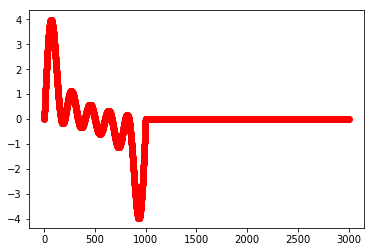

In [64]:
plt.plot(range(len(y)),y,'or')

In [70]:
tile_num=20
df = pd.DataFrame()
df['x1'] = np.tile(x1, tile_num)
df['x2'] = np.tile(x2, tile_num)
df['x3'] = np.tile(x3, tile_num)
df['x4'] = np.tile(x4, tile_num)
df['x5'] = np.tile(x5, tile_num)
df['y']  = np.tile(y, tile_num)



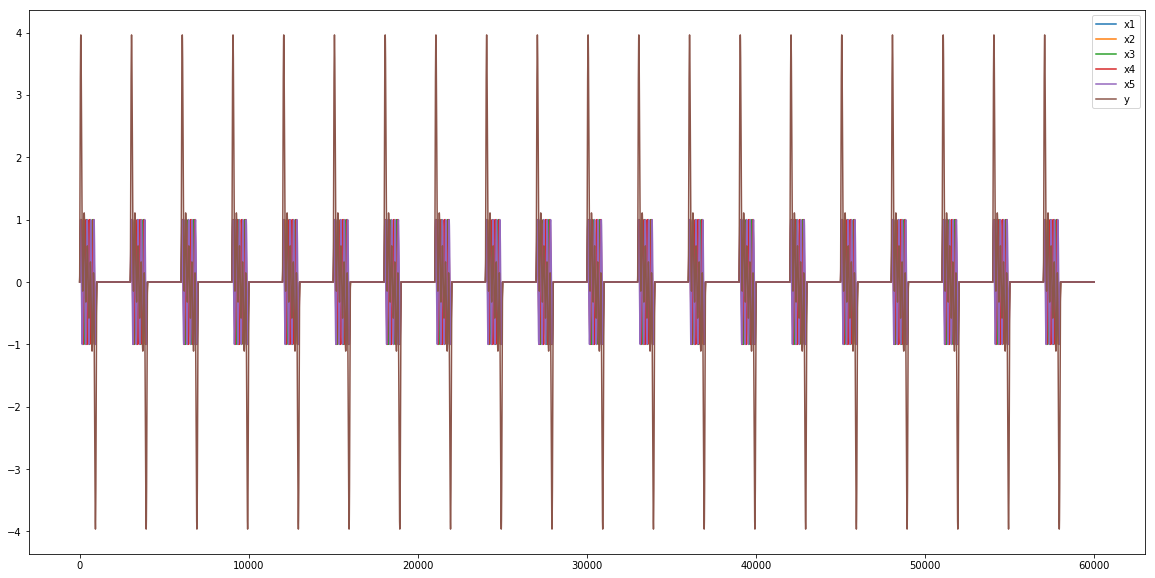

In [71]:
df.plot(figsize=(20,10))

In [187]:
df.to_csv('../input/synthetic.csv', index=None)

In [188]:
spy = pd.read_csv('../input/spy.csv')

In [189]:
def smooth_fit(arr, degree=1):
    spln = UnivariateSpline(range(len(arr)), y=arr, k=degree)
    return spln(range(len(adj)))

In [190]:
for colname in spy.columns:
    if colname != 'date':
        spy[colname] = smooth_fit(spy[colname].values)

C:\Users\ugurg\Anaconda3\lib\site-packages\scipy\interpolate\fitpack2.py:226: UserWarning: 
The maximal number of iterations maxit (set to 20 by the program)
allowed for finding a smoothing spline with fp=s has been reached: s
too small.
There is an approximation returned but the corresponding weighted sum
of squared residuals does not satisfy the condition abs(fp-s)/s < tol.
  warnings.warn(message)


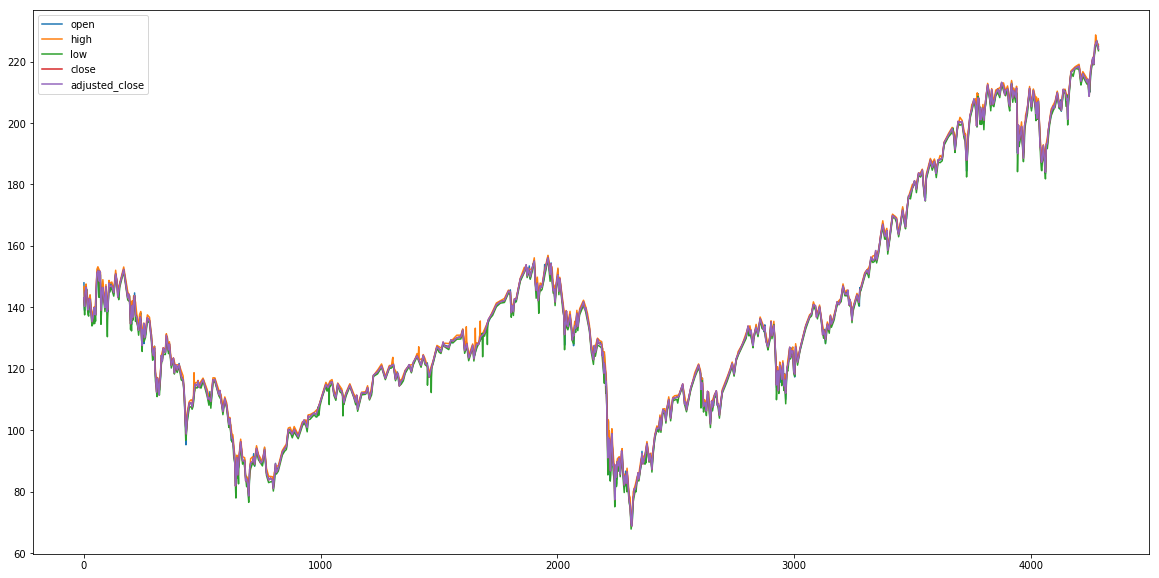

In [191]:
cols = list(spy.columns.values)
cols.remove('volume')

spy[cols].plot(figsize=(20,10))


In [193]:
spy.to_csv('../input/spy_spline.csv', index=None)

In [194]:
spy.mean()

open              1.377974e+02
high              1.386716e+02
low               1.368262e+02
close             1.377939e+02
volume            8.286467e+07
adjusted_close    1.377939e+02
dtype: float64

In [195]:
spy.var()

open              1.297275e+03
high              1.295311e+03
low               1.300284e+03
close             1.298149e+03
volume            7.041923e+15
adjusted_close    1.298149e+03
dtype: float64